# Notebook thử nghiệm sentiment

## Mục tiêu chính
- Chỉ tập trung vào 2 model: **Naive Bayes** và **Decision Tree**.
- Viết theo kiểu ghi chú học tập: đơn giản, dễ hiểu, hơi thủ công.
- Đảm bảo pipeline chạy đúng và cho kết quả đo lường rõ ràng.

## Kế hoạch làm việc trong notebook này
1. Đọc dữ liệu IMDB + SST và xem nhanh dữ liệu.
2. Tiền xử lý văn bản để giảm nhiễu.
3. Vector hóa văn bản bằng CountVectorizer và TF-IDF.
4. Huấn luyện + đánh giá Naive Bayes.
5. Huấn luyện + đánh giá Decision Tree.
6. So sánh kết quả cuối cùng và ghi chú bài học.

In [18]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None

# Bootstrap tối thiểu: chỉ cần đủ để import các module trong src.
BOOTSTRAP_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(BOOTSTRAP_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOTSTRAP_ROOT))

from src.preprocessing.text_processor import TextProcessor
from src.feature_extraction.count_vectorizer import CountVectorizer
from src.feature_extraction.tfidf_vectorizer import TfidfTransformer
from src.utils.helper import train_test_split
from src.evaluation.accuracy import accuracy
from src.evaluation.confusion_matrix import confusion_matrix
from src.models.naive_bayes.naive_bayes import NaiveBayes
from src.models.decision_tree.decision_tree import DecisionTree
from src.utils.notebook_setup import (
    find_csv_file,
    load_sentiment_dataset,
    resolve_project_root,
    summarize_dataset,
)

PROJECT_ROOT = resolve_project_root()
DATA_ROOT = PROJECT_ROOT / "data" / "raw"

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (12, 5)

# Phần đọc dữ liệu và thống kê đã được chuyển sang src/utils/notebook_setup.py.
imdb_path = find_csv_file(DATA_ROOT / "imdb")
sst_path = DATA_ROOT / "sst" / "train.csv"

imdb_bundle = load_sentiment_dataset(imdb_path, "IMDB")
sst_bundle = load_sentiment_dataset(sst_path, "SST")

imdb_summary, imdb_label_counts, imdb_lengths = summarize_dataset(imdb_bundle)
sst_summary, sst_label_counts, sst_lengths = summarize_dataset(sst_bundle)

summary_table = pd.concat([imdb_summary, sst_summary], ignore_index=True)
summary_table

,dataset,rows,unique_labels,avg_tokens,median_tokens,min_tokens,max_tokens
0,IMDB,50000,2,231.156940,173.0,4,2470
1,SST,67349,2,9.409553,7.0,1,52


## 1. Vì sao vẫn học model cổ điển?

Mình chọn Naive Bayes và Decision Tree vì 2 model này dễ hiểu về mặt trực giác:

- **Naive Bayes**: dựa vào xác suất và giả định độc lập đặc trưng.
- **Decision Tree**: chia nhánh theo điều kiện để phân loại.

Tuy không "xịn" như mô hình deep learning, nhưng nó giúp mình học chắc phần nền tảng:

1. Dữ liệu text đi qua pipeline như thế nào.
2. Feature ảnh hưởng ra sao đến model.
3. Vì sao model sai và cách kiểm tra lỗi.

## 2. Khám phá dữ liệu

Ở bước này mình chỉ cần trả lời mấy câu cơ bản:

- Dữ liệu có cột gì?
- Nhãn có cân bằng không?
- Độ dài text có quá lệch không?

Nếu dữ liệu lệch quá mạnh thì kết quả accuracy có thể nhìn đẹp nhưng không đáng tin.

In [7]:
print('IMDB raw columns:', list(imdb_bundle['raw'].columns))
print('SST raw columns:', list(sst_bundle['raw'].columns))

print('\nIMDB preview:')
display(imdb_bundle['raw'].head(3))

print('\nSST preview:')
display(sst_bundle['raw'].head(3))

print('\nNormalized summary table:')
display(summary_table)

IMDB raw columns: ['review', 'sentiment']
SST raw columns: ['id', 'target', 'sentence']

IMDB preview:


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as ...",positive
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and g...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater...",positive



SST preview:


,id,target,sentence
0,16399,0,b'for the uninitiated plays better on video with the sound '
1,1680,0,"b'like a giant commercial for universal studios , where much of the action takes place '"
2,47917,1,b'company once again dazzle and delight us '



Normalized summary table:


,dataset,rows,unique_labels,avg_tokens,median_tokens,min_tokens,max_tokens
0,IMDB,50000,2,231.156940,173.0,4,2470
1,SST,67349,2,9.409553,7.0,1,52


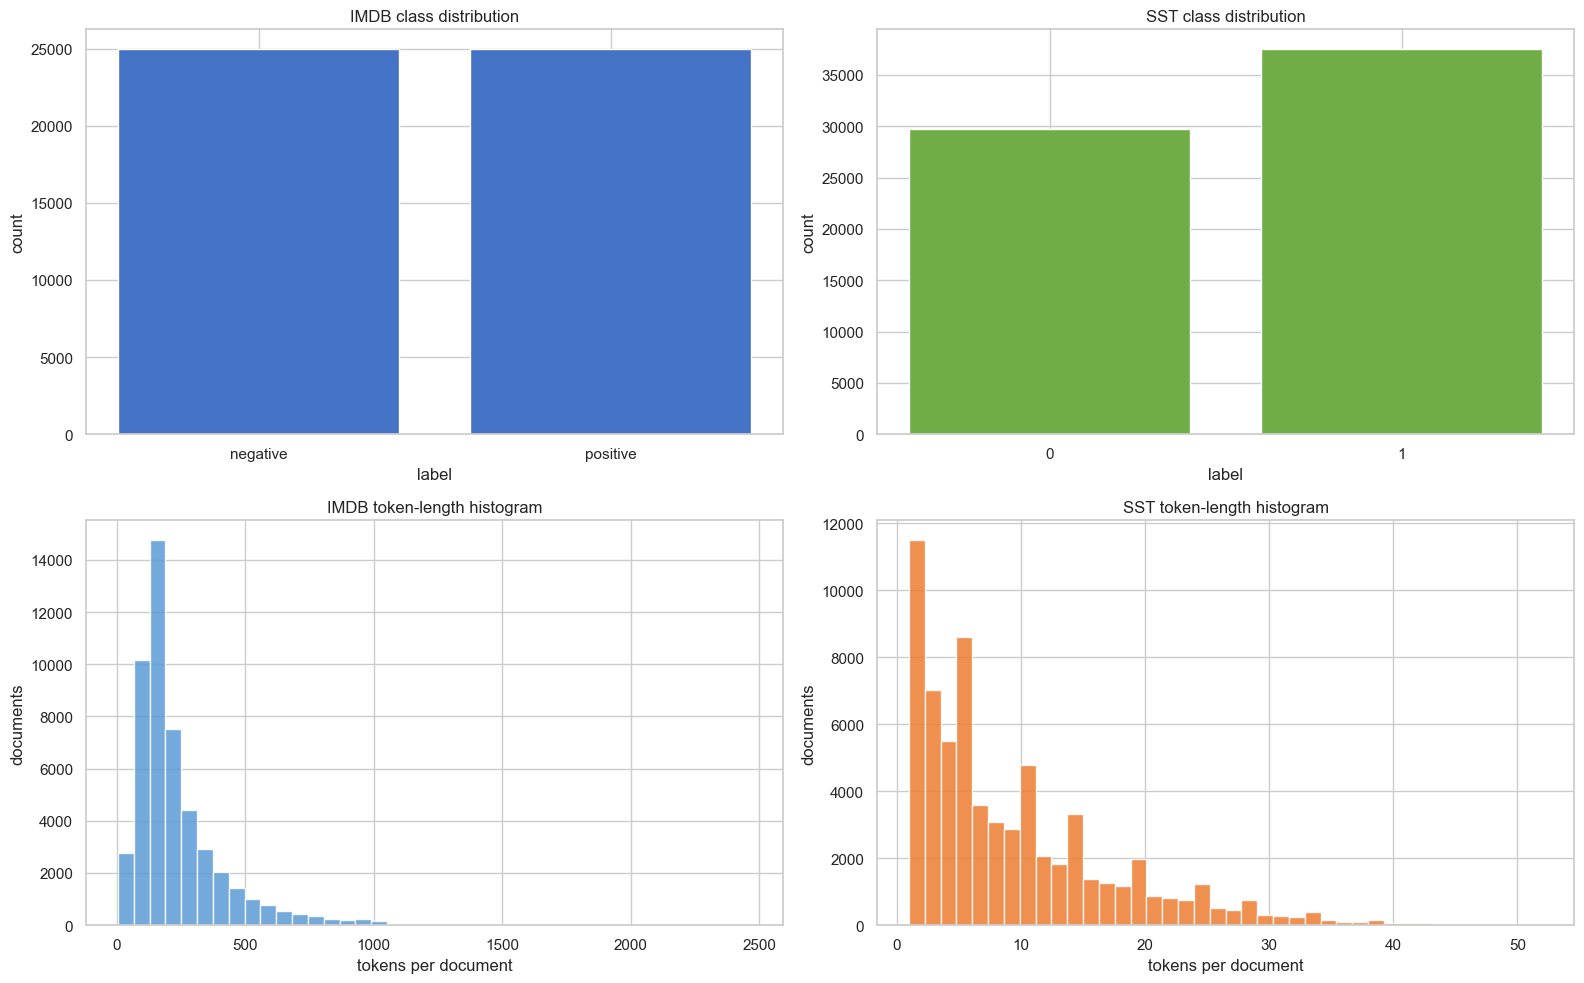

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Class distributions
axes[0, 0].bar(imdb_label_counts.index.astype(str), imdb_label_counts.values, color='#4472c4')
axes[0, 0].set_title('IMDB class distribution')
axes[0, 0].set_xlabel('label')
axes[0, 0].set_ylabel('count')

axes[0, 1].bar(sst_label_counts.index.astype(str), sst_label_counts.values, color='#70ad47')
axes[0, 1].set_title('SST class distribution')
axes[0, 1].set_xlabel('label')
axes[0, 1].set_ylabel('count')

# Text length histograms
axes[1, 0].hist(imdb_lengths, bins=40, color='#5b9bd5', alpha=0.85)
axes[1, 0].set_title('IMDB token-length histogram')
axes[1, 0].set_xlabel('tokens per document')
axes[1, 0].set_ylabel('documents')

axes[1, 1].hist(sst_lengths, bins=40, color='#ed7d31', alpha=0.85)
axes[1, 1].set_title('SST token-length histogram')
axes[1, 1].set_xlabel('tokens per document')
axes[1, 1].set_ylabel('documents')

plt.tight_layout()

## 3. Tiền xử lý text

Phần này mình giữ kiểu đơn giản để dễ theo dõi:

1. Làm sạch text cơ bản (chữ thường, bỏ nhiễu).
2. Tách token.
3. So sánh trước/sau tiền xử lý để xem có bị mất thông tin nhiều không.

Mục tiêu là tạo đầu vào sạch cho vectorizer, không phải tối ưu cực hạn.

In [9]:
processor = TextProcessor(remove_stopwords=True, remove_numbers=True)
preprocess_samples = (
    imdb_bundle['data']['text'].dropna().sample(3, random_state=42).tolist()
    + sst_bundle['data']['text'].dropna().sample(3, random_state=42).tolist()
)

preprocess_rows = []
for sample in preprocess_samples:
    cleaned = processor.clean(sample)
    tokens = processor.process(sample)
    preprocess_rows.append({
        'raw_text': sample[:180],
        'cleaned_text': cleaned[:180],
        'tokens': ' '.join(tokens[:25]),
        'token_count': len(tokens),
    })

preprocess_demo = pd.DataFrame(preprocess_rows)
preprocess_demo

,raw_text,cleaned_text,tokens,token_count
0,"I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting ...",i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting t...,really liked summerslam due look arena curtains just look overall was interesting me some reason anyways one best su...,137
1,Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and...,not many television shows appeal to quite as many different kinds of fans like farscape does i know youngsters and y...,not many television shows appeal quite as many different kinds fans like farscape know youngsters years old fans bot...,224
2,The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy...,the film quickly gets to a major chase scene with ever increasing destruction the first really bad thing is the guy ...,film quickly gets major chase scene ever increasing destruction first really bad thing guy hijacking steven seagal b...,70
3,"is , truly and thankfully , a one-of-a-kind work",is truly and thankfully a one of a kind work,truly thankfully one kind work,5
4,the clumsy cliché,the clumsy cliché,clumsy cliché,2
5,fuddled,fuddled,fuddled,1


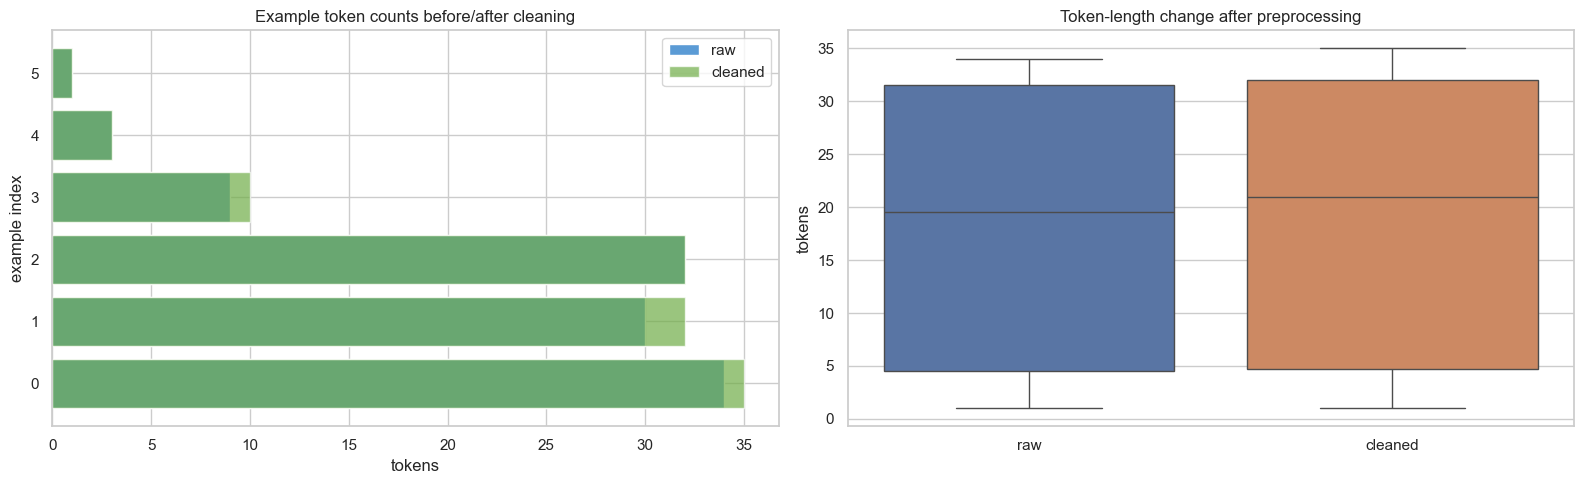

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample_frame = preprocess_demo.copy()
sample_frame['raw_len'] = sample_frame['raw_text'].map(lambda text: len(str(text).split()))
sample_frame['clean_len'] = sample_frame['cleaned_text'].map(lambda text: len(str(text).split()))

axes[0].barh(range(len(sample_frame)), sample_frame['raw_len'], color='#5b9bd5', label='raw')
axes[0].barh(range(len(sample_frame)), sample_frame['clean_len'], color='#70ad47', alpha=0.7, label='cleaned')
axes[0].set_title('Example token counts before/after cleaning')
axes[0].set_xlabel('tokens')
axes[0].set_ylabel('example index')
axes[0].legend()

if sns is not None:
    sns.boxplot(data=pd.DataFrame({'raw': sample_frame['raw_len'], 'cleaned': sample_frame['clean_len']}), ax=axes[1])
else:
    axes[1].boxplot([sample_frame['raw_len'], sample_frame['clean_len']], labels=['raw', 'cleaned'])
axes[1].set_title('Token-length change after preprocessing')
axes[1].set_ylabel('tokens')

plt.tight_layout()

## 4. Trích xuất đặc trưng

Mình dùng 2 kiểu biểu diễn quen thuộc:

- **Count (BoW)**: dễ hiểu, dễ debug.
- **TF-IDF**: giảm ảnh hưởng của từ quá phổ biến.

Sau khi vector hóa, mình tách train/test rõ ràng để tránh data leakage.
Lưu ý nhỏ: Decision Tree trong repo này chạy tốt hơn khi đầu vào là mảng dense và nhãn dạng số.

In [13]:
# Dùng IMDB cho bài toán nhị phân để notebook chạy nhanh và dễ quan sát
feature_sample = imdb_bundle['data'].dropna(subset=['text', 'label']).sample(min(1000, len(imdb_bundle['data'])), random_state=42).copy()
feature_sample['processed_text'] = feature_sample['text'].map(lambda text: ' '.join(processor.process(text)))

# Mã hóa nhãn sang số để tránh lỗi kiểu dữ liệu khi fit Decision Tree
label_codes, label_uniques = pd.factorize(feature_sample['label'])
label_to_name = {int(i): str(name) for i, name in enumerate(label_uniques)}

feature_texts = feature_sample['processed_text'].tolist()
feature_labels = label_codes.astype(int)

feature_train_text, feature_test_text, feature_train_y, feature_test_y = train_test_split(
    np.array(feature_texts),
    np.array(feature_labels),
    test_size=0.2,
    random_state=42,
    stratify=True,
)

vectorizer = CountVectorizer(lowercase=True, ngram_range=(1, 2), max_features=2500)
X_train_counts = vectorizer.fit_transform(feature_train_text)
X_test_counts = vectorizer.transform(feature_test_text)

tfidf = TfidfTransformer()
X_train_tfidf = tfidf.fit_transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)

vocab_size = len(vectorizer.vocabulary_)
train_sparsity = 1.0 - (X_train_counts.nnz / (X_train_counts.shape[0] * X_train_counts.shape[1]))
tfidf_norms = np.sqrt(np.asarray(X_train_tfidf.power(2).sum(axis=1)).ravel())

column_sums = np.asarray(X_train_counts.sum(axis=0)).ravel()
inv_vocab = {index: token for token, index in vectorizer.vocabulary_.items()}
top_term_indices = np.argsort(column_sums)[-15:][::-1]
top_terms = pd.DataFrame({
    'token': [inv_vocab[index] for index in top_term_indices],
    'count': column_sums[top_term_indices],
})

feature_summary = pd.DataFrame({
    'metric': ['vocab_size', 'train_rows', 'train_cols', 'nnz', 'sparsity', 'tfidf_row_norm_mean'],
    'value': [vocab_size, X_train_counts.shape[0], X_train_counts.shape[1], X_train_counts.nnz, train_sparsity, tfidf_norms.mean()],
})

feature_bundle = {
    'train_text': feature_train_text,
    'test_text': feature_test_text,
    'train_y': feature_train_y,
    'test_y': feature_test_y,
    'label_to_name': label_to_name,
    'count_vectorizer': vectorizer,
    'tfidf_transformer': tfidf,
    'X_train_counts': X_train_counts,
    'X_test_counts': X_test_counts,
    'X_train_tfidf': X_train_tfidf,
    'X_test_tfidf': X_test_tfidf,
}

display(feature_summary)
display(top_terms)

,metric,value
0,vocab_size,2500.000000
1,train_rows,799.000000
2,train_cols,2500.000000
3,nnz,72233.000000
4,sparsity,0.963838
5,tfidf_row_norm_mean,1.000000


,token,count
0,was,1625.0
1,movie,1430.0
2,as,1427.0
3,film,1290.0
4,not,1011.0
5,his,903.0
6,one,846.0
7,all,776.0
8,like,700.0
9,so,674.0


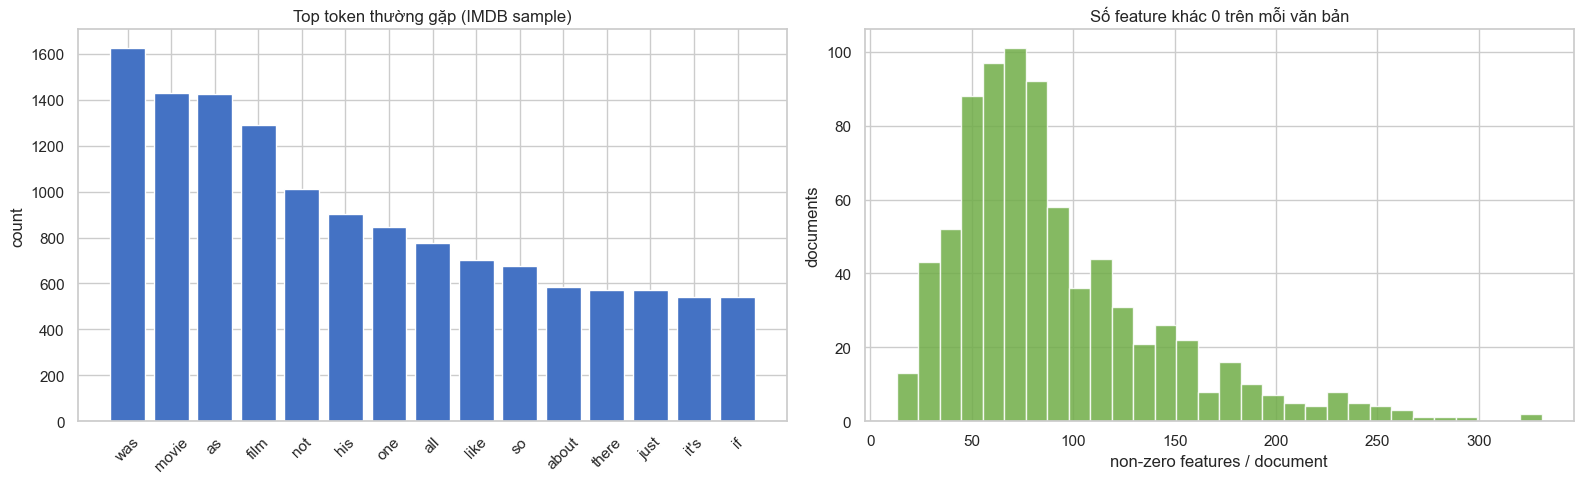

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(top_terms['token'], top_terms['count'], color='#4472c4')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Top token thường gặp (IMDB sample)')
axes[0].set_ylabel('count')

axes[1].hist(np.asarray(X_train_counts.getnnz(axis=1)).ravel(), bins=30, color='#70ad47', alpha=0.85)
axes[1].set_title('Số feature khác 0 trên mỗi văn bản')
axes[1].set_xlabel('non-zero features / document')
axes[1].set_ylabel('documents')

plt.tight_layout()

## 5. Thực nghiệm model

Phần này chỉ còn đúng 2 model:

1. Naive Bayes
2. Decision Tree

Mình chạy trên cùng tập train/test để so sánh công bằng, sau đó xem accuracy + precision/recall/f1 + confusion matrix.

### 5.1. Naive Bayes

Ý tưởng ngắn gọn: đếm mức độ xuất hiện từ trong từng lớp rồi tính xác suất có làm trơn (Laplace).

Ở đây mình thử trên cả Count và TF-IDF để xem kiểu feature nào hợp hơn.

In [14]:
def compute_classification_metrics(y_true, y_pred):
    cm, classes = confusion_matrix(y_true, y_pred)
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0).astype(float) - tp
    fn = cm.sum(axis=1).astype(float) - tp

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) != 0)

    return {
        'classes': classes,
        'cm': cm,
        'accuracy': accuracy(y_true, y_pred),
        'precision_macro': precision.mean(),
        'recall_macro': recall.mean(),
        'f1_macro': f1.mean(),
    }


def evaluate_model(model_name, model, X_train, X_test, y_train, y_test, feature_name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = compute_classification_metrics(y_test, pred)
    return {
        'model': model_name,
        'feature': feature_name,
        'accuracy': metrics['accuracy'],
        'precision_macro': metrics['precision_macro'],
        'recall_macro': metrics['recall_macro'],
        'f1_macro': metrics['f1_macro'],
        'cm': metrics['cm'],
    }

print('Helper metrics đã sẵn sàng.')

Helper metrics đã sẵn sàng.


### 5.2. Decision Tree

Decision Tree dễ bị overfit trên dữ liệu text nhiều chiều, nên mình giữ tree nông (max_depth nhỏ) để chạy ổn định và dễ đọc kết quả.

Mục tiêu ở đây là nhìn cách tree phản ứng với Count vs TF-IDF, không phải đẩy điểm số cao nhất.

In [15]:
nb_results = []

nb_results.append(
    evaluate_model(
        model_name='Naive Bayes',
        model=NaiveBayes(alpha=1.0),
        X_train=feature_bundle['X_train_counts'],
        X_test=feature_bundle['X_test_counts'],
        y_train=feature_bundle['train_y'],
        y_test=feature_bundle['test_y'],
        feature_name='Count',
    )
)

nb_results.append(
    evaluate_model(
        model_name='Naive Bayes',
        model=NaiveBayes(alpha=1.0),
        X_train=feature_bundle['X_train_tfidf'],
        X_test=feature_bundle['X_test_tfidf'],
        y_train=feature_bundle['train_y'],
        y_test=feature_bundle['test_y'],
        feature_name='TF-IDF',
    )
)

nb_results_df = pd.DataFrame([{k: v for k, v in row.items() if k != 'cm'} for row in nb_results]).sort_values('f1_macro', ascending=False)
nb_results_df

,model,feature,accuracy,precision_macro,recall_macro,f1_macro
0,Naive Bayes,Count,0.79602,0.805198,0.791815,0.792549
1,Naive Bayes,TF-IDF,0.79602,0.829186,0.788690,0.787609


In [16]:
dt_results = []

# Tree nông để giảm overfit + giữ thời gian chạy hợp lý trong notebook
dt_results.append(
    evaluate_model(
        model_name='Decision Tree',
        model=DecisionTree(min_samples_split=5, max_depth=8),
        X_train=feature_bundle['X_train_counts'],
        X_test=feature_bundle['X_test_counts'],
        y_train=feature_bundle['train_y'],
        y_test=feature_bundle['test_y'],
        feature_name='Count',
    )
)

dt_results.append(
    evaluate_model(
        model_name='Decision Tree',
        model=DecisionTree(min_samples_split=5, max_depth=8),
        X_train=feature_bundle['X_train_tfidf'],
        X_test=feature_bundle['X_test_tfidf'],
        y_train=feature_bundle['train_y'],
        y_test=feature_bundle['test_y'],
        feature_name='TF-IDF',
    )
)

dt_results_df = pd.DataFrame([{k: v for k, v in row.items() if k != 'cm'} for row in dt_results]).sort_values('f1_macro', ascending=False)
dt_results_df

,model,feature,accuracy,precision_macro,recall_macro,f1_macro
0,Decision Tree,Count,0.691542,0.710794,0.697619,0.688138
1,Decision Tree,TF-IDF,0.676617,0.717046,0.685565,0.667091


,model,feature,accuracy,precision_macro,recall_macro,f1_macro
0,Naive Bayes,Count,0.796020,0.805198,0.791815,0.792549
1,Naive Bayes,TF-IDF,0.796020,0.829186,0.788690,0.787609
2,Decision Tree,Count,0.691542,0.710794,0.697619,0.688138
3,Decision Tree,TF-IDF,0.676617,0.717046,0.685565,0.667091


Cấu hình tốt nhất theo F1: Naive Bayes + Count


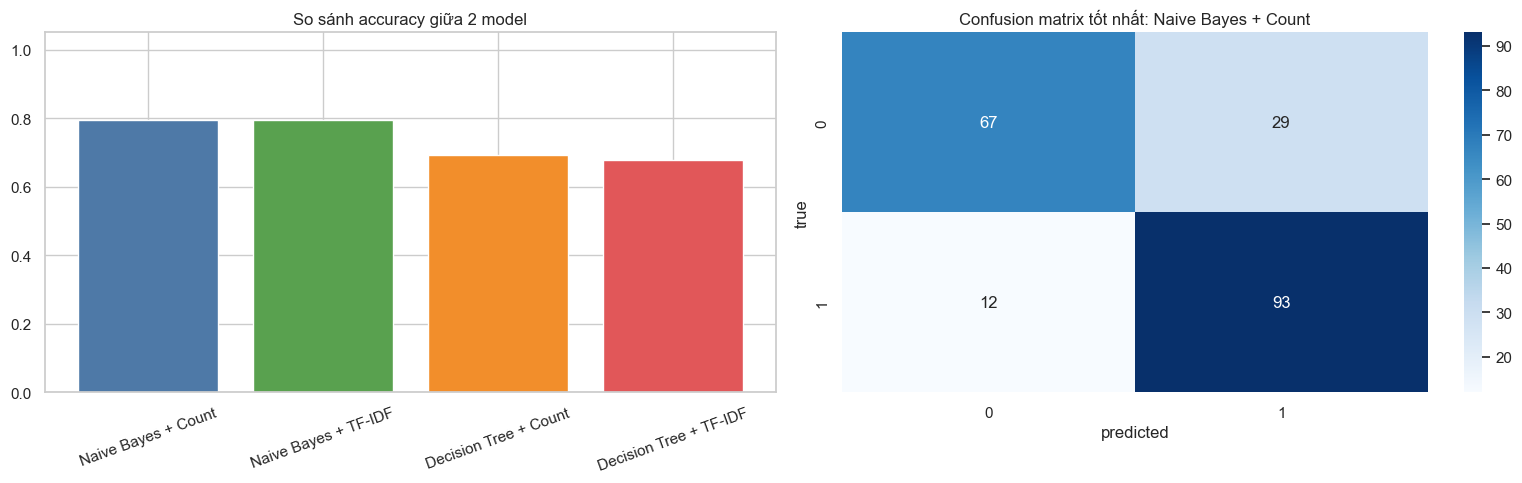

In [17]:
all_results = nb_results + dt_results
all_results_df = pd.DataFrame([{k: v for k, v in row.items() if k != 'cm'} for row in all_results]).sort_values('f1_macro', ascending=False).reset_index(drop=True)

display(all_results_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ so sánh accuracy
label_names = all_results_df['model'] + ' + ' + all_results_df['feature']
axes[0].bar(label_names, all_results_df['accuracy'], color=['#4e79a7', '#59a14f', '#f28e2b', '#e15759'])
axes[0].set_title('So sánh accuracy giữa 2 model')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=20)

# Confusion matrix của cấu hình tốt nhất theo F1
best_idx = all_results_df['f1_macro'].idxmax()
best_model_name = all_results_df.loc[best_idx, 'model']
best_feature_name = all_results_df.loc[best_idx, 'feature']
best_cm = next(row['cm'] for row in all_results if row['model'] == best_model_name and row['feature'] == best_feature_name)

if sns is not None:
    sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
else:
    axes[1].imshow(best_cm, cmap='Blues')
axes[1].set_title(f'Confusion matrix tốt nhất: {best_model_name} + {best_feature_name}')
axes[1].set_xlabel('predicted')
axes[1].set_ylabel('true')

plt.tight_layout()

print('Cấu hình tốt nhất theo F1:', best_model_name, '+', best_feature_name)

## 6. Kết luận

Mấy điều mình rút ra sau khi chạy:

1. Cùng một model nhưng đổi feature (Count/TF-IDF) có thể làm kết quả thay đổi khá nhiều.
2. Naive Bayes thường ổn định và chạy nhanh cho bài toán text BoW.
3. Decision Tree dễ overfit nếu để cây quá sâu.
4. Quy trình train/test rõ ràng quan trọng hơn việc cố tweak hyperparameter quá sớm.

Hướng làm tiếp nếu có thời gian:

- thử đổi `max_features` của vectorizer
- thử tăng/giảm `max_depth` của tree
- đọc các mẫu dự đoán sai để hiểu lỗi theo ngữ cảnh câu